# Single-Layer to Multi-Graph Composition

This notebook verifies the empirical subadditive composition law from packaged graph-rewrite results.


In [1]:
import json
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import pearsonr, spearmanr

ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
DATA = ROOT / 'results' / 'data'

def load(name):
    with open(DATA / name) as handle:
        return json.load(handle)

def composition(data, field='symmetric_kl'):
    rows = data['rows']
    baseline = next(row[field] for row in rows if sum(row['bits']) == 0)
    singles = {}
    for row in rows:
        if sum(row['bits']) == 1:
            singles[row['bits'].index(1)] = row[field] - baseline
    predicted, actual = [], []
    for row in rows:
        if sum(row['bits']) < 2:
            continue
        predicted.append(sum(singles[i] for i, bit in enumerate(row['bits']) if bit))
        actual.append(row[field] - baseline)
    predicted, actual = np.asarray(predicted), np.asarray(actual)
    slope = np.dot(predicted, actual) / np.dot(predicted, predicted)
    return predicted, actual, slope


ClimbMix {'spearman': 0.929, 'pearson': 0.962, 'slope': 0.715}
TinyStories {'spearman': 0.95, 'pearson': 0.969, 'slope': 0.702}


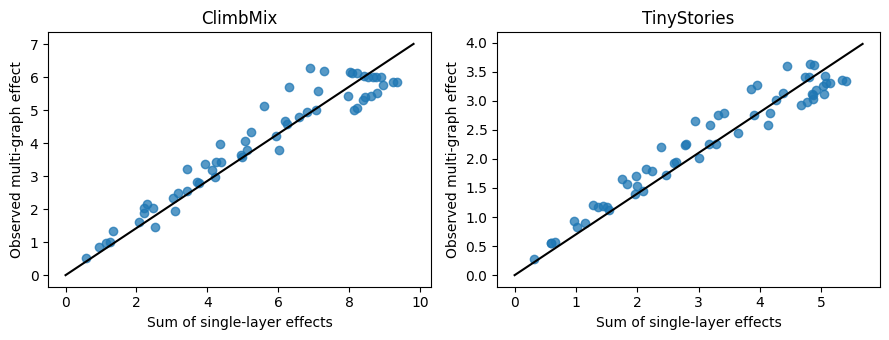

In [2]:
fig, axes = plt.subplots(1, 2, figsize=(9, 3.5))
for axis, (label, filename) in zip(axes, [('ClimbMix', 'climbmix_graphs.json'), ('TinyStories', 'tinystories_graphs.json')]):
    predicted, actual, slope = composition(load(filename))
    print(label, {
        'spearman': round(float(spearmanr(predicted, actual).statistic), 3),
        'pearson': round(float(pearsonr(predicted, actual).statistic), 3),
        'slope': round(float(slope), 3),
    })
    limit = 1.05 * max(predicted.max(), actual.max())
    axis.scatter(predicted, actual, alpha=0.75)
    axis.plot([0, limit], [0, slope * limit], color='black')
    axis.set_title(label)
    axis.set_xlabel('Sum of single-layer effects')
    axis.set_ylabel('Observed multi-graph effect')
plt.tight_layout()
plt.show()


## Compiler interpretation

A calibrated coefficient near 0.7 maps sums of single-layer effects to multi-graph divergence. The compiler enumerates all 4,096 masks for a 12-layer model and maximizes the number of parallel layers under a divergence budget. Aggregate held-out and cross-corpus prediction are strong; prompt-specific defects remain rankers rather than reliable 95% certificates.
